In [1]:
import sys
import os
my_path = os.path.dirname(os.getcwd())
sys.path.append(my_path)

# from prev_ob_models.Doxey2022.isolated_cells import *
import prev_ob_models.Doxey2022.isolated_cells as ic
from neuron import h, gui, load_mechanisms
import matplotlib.pyplot as plt
import random

--No graphics will be displayed.


In [2]:
if not os.path.isdir('../prev_ob_models/Doxey2022/Mechanisms/x86_64'):
    os.system('python ../prev_ob_models/Doxey2022/compile_mechs.py')
else:
    print('Mechanisms already compiled')
# ! python ../prev_ob_models/Doxey2022/compile_mechs.py

Mechanisms already compiled


In [3]:
def load_cell(my_cell):
    # Load and return all sections of a neuron hoc file
    neuron_path = "%s/prev_ob_models/Doxey2022/Cells/%s.hoc" % (my_path, my_cell)
    print(neuron_path)
    h.load_file(neuron_path)
    cell = getattr(h, my_cell)()  # to change cell name string to accessible attribute

    # Retrieve all sections and filter based on the cell type
    secs = [sec for sec in h.allsec() if my_cell in sec.name()]
    #for sec in secs:
    #    print(sec)

    return h, cell, secs


In [4]:
def get_apics(cell_names):
    # Dictionary to store apical sections for each cell
    apical_sections_dict = {}

    # Iterate through each cell name provided in the list
    for cell_name in cell_names:
        # Load the cell and get all its sections
        _, _, sections = load_cell(cell_name)

        # Filter apical sections for the current cell
        apics = []
        for sec in sections:
            section_name = sec.name()
            if 'apic' in section_name:
                apics.append(section_name)
            elif 'soma' in section_name:
                print(f'skipping soma {section_name}')
        
        # Store all the apical sections in the dictionary
        apical_sections_dict[cell_name] = apics

    return apical_sections_dict

def add_index_to_sections(sections_dict, index):
    new_dict = {}
    for key, section_list in sections_dict.items():
        # Apply the index to each section in the list
        new_sections = [f"{section}({index})" for section in section_list]
        new_dict[key] = new_sections
    return new_dict


In [5]:
cvode = h.CVode()
cvode.active(0)  # Disable variable time step to ensure deterministic behavior
delay = 200
dur = 700
h.tstop = 1000
h.celsius = 35
h.steps_per_ms = 10
h.dt = 0.1 # 1.0 / h.steps_per_ms
gc_cells = [ic.GC1(), ic.GC2(), ic.GC3(), ic.GC4(), ic.GC5()]

Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.


In [6]:
cell_names = ['GC1', 'GC2', 'GC3', 'GC4', 'GC5']
apical_sections = get_apics(cell_names)

apical_sections

/home/ellismith/OlfactoryBulb-1/prev_ob_models/Doxey2022/Cells/GC1.hoc
skipping soma GC1[0].soma
skipping soma GC1[2].soma
/home/ellismith/OlfactoryBulb-1/prev_ob_models/Doxey2022/Cells/GC2.hoc
skipping soma GC2[0].soma
skipping soma GC2[2].soma
/home/ellismith/OlfactoryBulb-1/prev_ob_models/Doxey2022/Cells/GC3.hoc
skipping soma GC3[0].soma
skipping soma GC3[2].soma
/home/ellismith/OlfactoryBulb-1/prev_ob_models/Doxey2022/Cells/GC4.hoc
skipping soma GC4[0].soma
skipping soma GC4[2].soma
/home/ellismith/OlfactoryBulb-1/prev_ob_models/Doxey2022/Cells/GC5.hoc
skipping soma GC5[0].soma
skipping soma GC5[2].soma


{'GC1': ['GC1[0].apic[0]',
  'GC1[0].apic[1]',
  'GC1[0].apic[2]',
  'GC1[0].apic[3]',
  'GC1[0].apic[4]',
  'GC1[0].apic[5]',
  'GC1[0].apic[6]',
  'GC1[0].apic[7]',
  'GC1[0].apic[8]',
  'GC1[0].apic[9]',
  'GC1[0].apic[10]',
  'GC1[2].apic[0]',
  'GC1[2].apic[1]',
  'GC1[2].apic[2]',
  'GC1[2].apic[3]',
  'GC1[2].apic[4]',
  'GC1[2].apic[5]',
  'GC1[2].apic[6]',
  'GC1[2].apic[7]',
  'GC1[2].apic[8]',
  'GC1[2].apic[9]',
  'GC1[2].apic[10]'],
 'GC2': ['GC2[0].apic[0]',
  'GC2[0].apic[1]',
  'GC2[0].apic[2]',
  'GC2[0].apic[3]',
  'GC2[0].apic[4]',
  'GC2[0].apic[5]',
  'GC2[0].apic[6]',
  'GC2[0].apic[7]',
  'GC2[0].apic[8]',
  'GC2[2].apic[0]',
  'GC2[2].apic[1]',
  'GC2[2].apic[2]',
  'GC2[2].apic[3]',
  'GC2[2].apic[4]',
  'GC2[2].apic[5]',
  'GC2[2].apic[6]',
  'GC2[2].apic[7]',
  'GC2[2].apic[8]'],
 'GC3': ['GC3[0].apic[0]',
  'GC3[0].apic[1]',
  'GC3[0].apic[2]',
  'GC3[0].apic[3]',
  'GC3[0].apic[4]',
  'GC3[0].apic[5]',
  'GC3[0].apic[6]',
  'GC3[0].apic[7]',
  'GC3[0].apic[

In [7]:
index_value = 1
distal_sections = add_index_to_sections(apical_sections, index_value)
distal_sections

{'GC1': ['GC1[0].apic[0](1)',
  'GC1[0].apic[1](1)',
  'GC1[0].apic[2](1)',
  'GC1[0].apic[3](1)',
  'GC1[0].apic[4](1)',
  'GC1[0].apic[5](1)',
  'GC1[0].apic[6](1)',
  'GC1[0].apic[7](1)',
  'GC1[0].apic[8](1)',
  'GC1[0].apic[9](1)',
  'GC1[0].apic[10](1)',
  'GC1[2].apic[0](1)',
  'GC1[2].apic[1](1)',
  'GC1[2].apic[2](1)',
  'GC1[2].apic[3](1)',
  'GC1[2].apic[4](1)',
  'GC1[2].apic[5](1)',
  'GC1[2].apic[6](1)',
  'GC1[2].apic[7](1)',
  'GC1[2].apic[8](1)',
  'GC1[2].apic[9](1)',
  'GC1[2].apic[10](1)'],
 'GC2': ['GC2[0].apic[0](1)',
  'GC2[0].apic[1](1)',
  'GC2[0].apic[2](1)',
  'GC2[0].apic[3](1)',
  'GC2[0].apic[4](1)',
  'GC2[0].apic[5](1)',
  'GC2[0].apic[6](1)',
  'GC2[0].apic[7](1)',
  'GC2[0].apic[8](1)',
  'GC2[2].apic[0](1)',
  'GC2[2].apic[1](1)',
  'GC2[2].apic[2](1)',
  'GC2[2].apic[3](1)',
  'GC2[2].apic[4](1)',
  'GC2[2].apic[5](1)',
  'GC2[2].apic[6](1)',
  'GC2[2].apic[7](1)',
  'GC2[2].apic[8](1)'],
 'GC3': ['GC3[0].apic[0](1)',
  'GC3[0].apic[1](1)',
  'GC3[0]

## Load cells

In [6]:
mc_cells = [ic.MC1(), ic.MC2(), ic.MC3(), ic.MC4(), ic.MC5()]
tc_cells = [ic.TC1(), ic.TC2(), ic.TC3(), ic.TC4(), ic.TC5()]
gc_cells = [ic.GC1(), ic.GC2(), ic.GC3(), ic.GC4(), ic.GC5()]
# gc_cell = ic.GC3()

Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.


## Initialize h

In [7]:
h.cvode_active(0)

delay = 200
dur = 700
h.tstop = 1000
h.celsius = 35
h.steps_per_ms = 10
h.dt = 1.0 / h.steps_per_ms



## Mitral Cells

In [10]:
mc_amps = [0.25, 0, -0.1]
# mc_amps = [0.2+(amp*0.01) for amp in list(range(0,10))]
#mc_amps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

num_mc_cells = len(mc_cells)

Text(0, 0.5, 'Ca current (mA/cm2)')

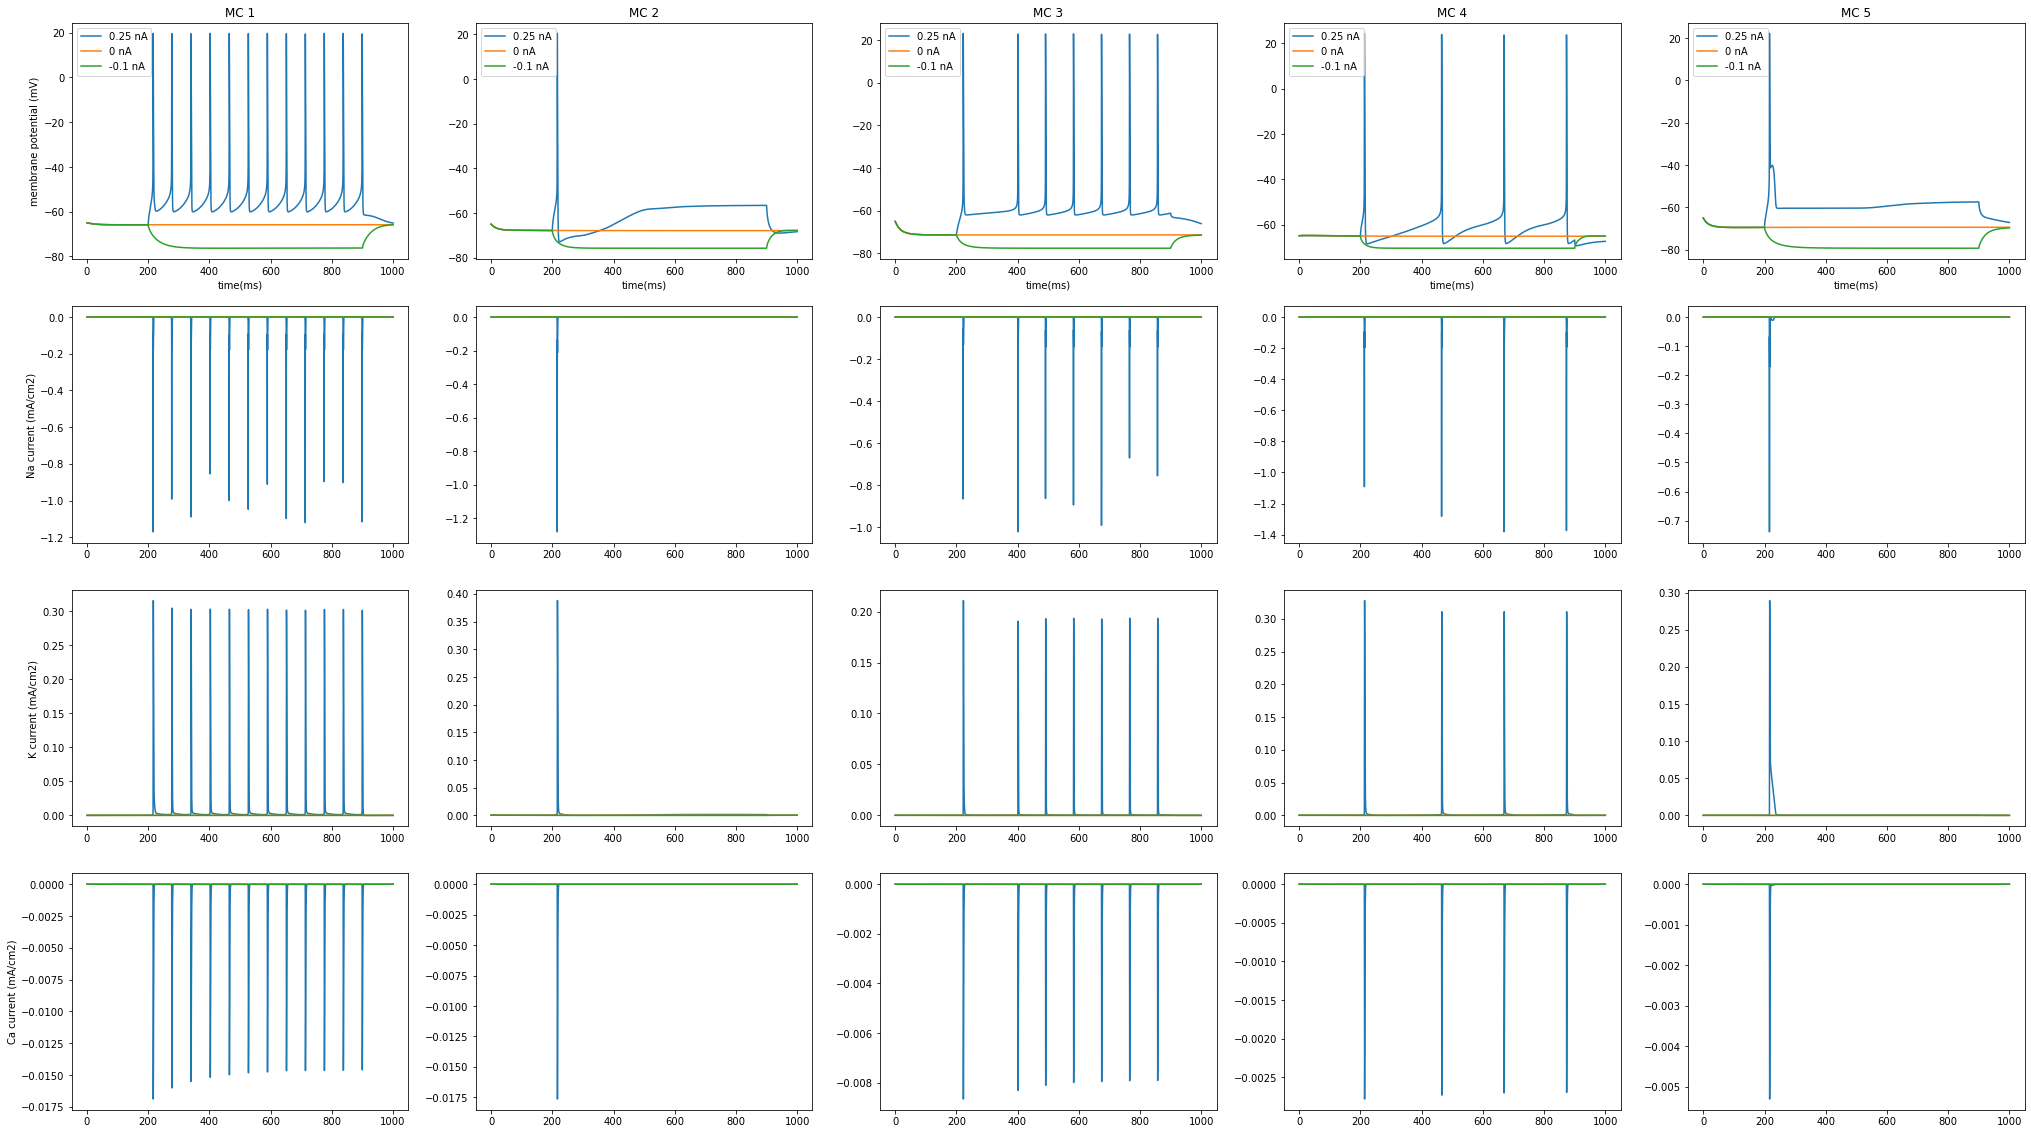

In [11]:
fig, axs = plt.subplots(4, num_mc_cells, figsize=(35,20), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(mc_cells):
    for amp in mc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)
        iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
        iK = h.Vector().record(cell.soma(0.5)._ref_ik)
        iCa = h.Vector().record(cell.soma(0.5)._ref_ica)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_mc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_mc_cells].plot(t, iK, label=f'{amp} nA')
        axs[idx+3*num_mc_cells].plot(t, iCa, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')
axs[15].set_ylabel('Ca current (mA/cm2)')

## Tufted Cells

In [13]:
tc_amps = [0.25, 0, -0.1]

num_tc_cells = len(tc_cells)

Text(0, 0.5, 'Ca current (mA/cm2)')

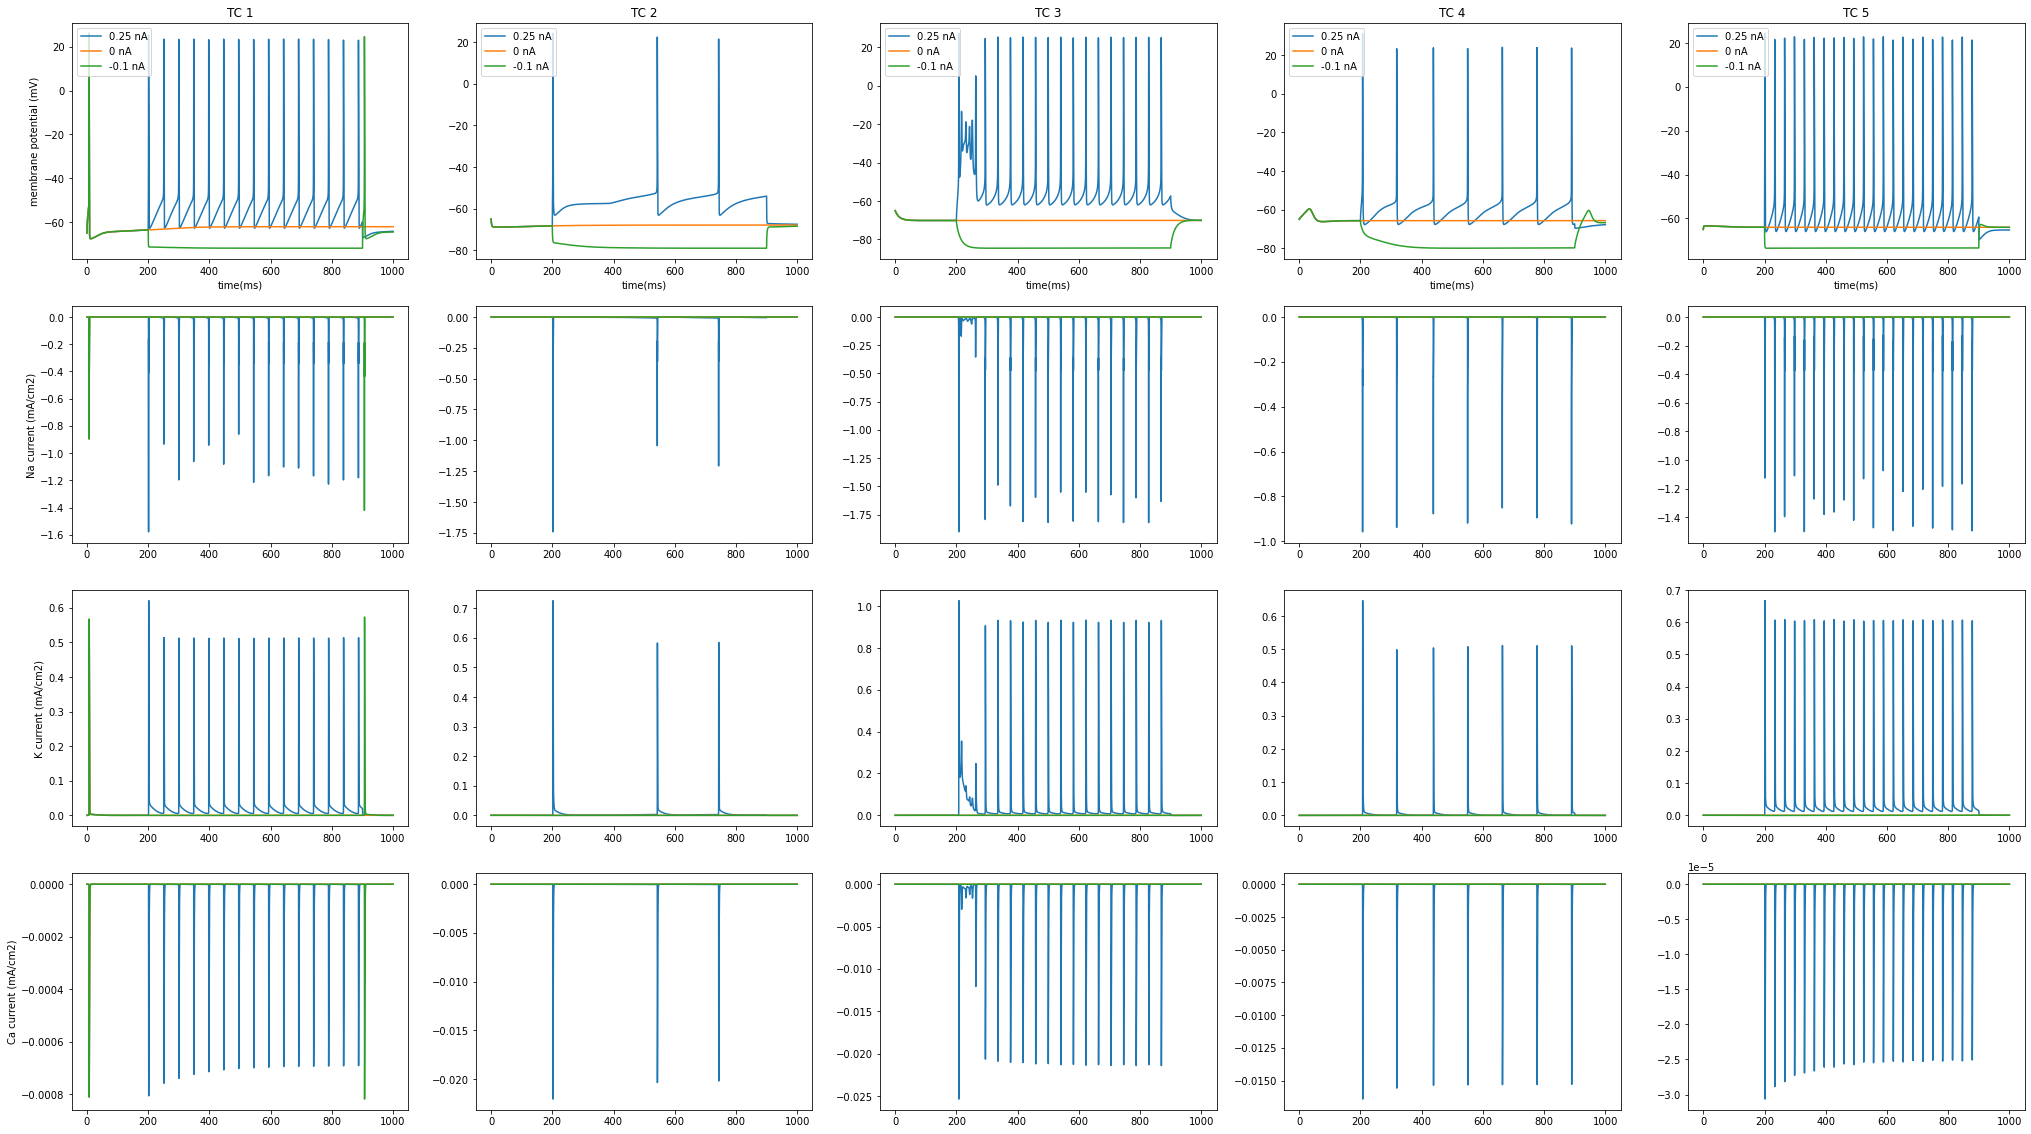

In [14]:
fig, axs = plt.subplots(4, num_tc_cells, figsize=(35,20), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(tc_cells):
    for amp in tc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)
        iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
        iK = h.Vector().record(cell.soma(0.5)._ref_ik)
        iCa = h.Vector().record(cell.soma(0.5)._ref_ica)
        
        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_tc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_tc_cells].plot(t, iK, label=f'{amp} nA')
        axs[idx+3*num_tc_cells].plot(t, iCa, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')
axs[15].set_ylabel('Ca current (mA/cm2)')

## Granule Cells

In [12]:
gc_cells = [ic.GC1(), ic.GC2(), ic.GC3(), ic.GC4(), ic.GC5()]
gc_amps = [0.06, 0, -0.02]

num_gc_cells = len(gc_cells)

Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.


Text(0, 0.5, 'K current (mA/cm2)')

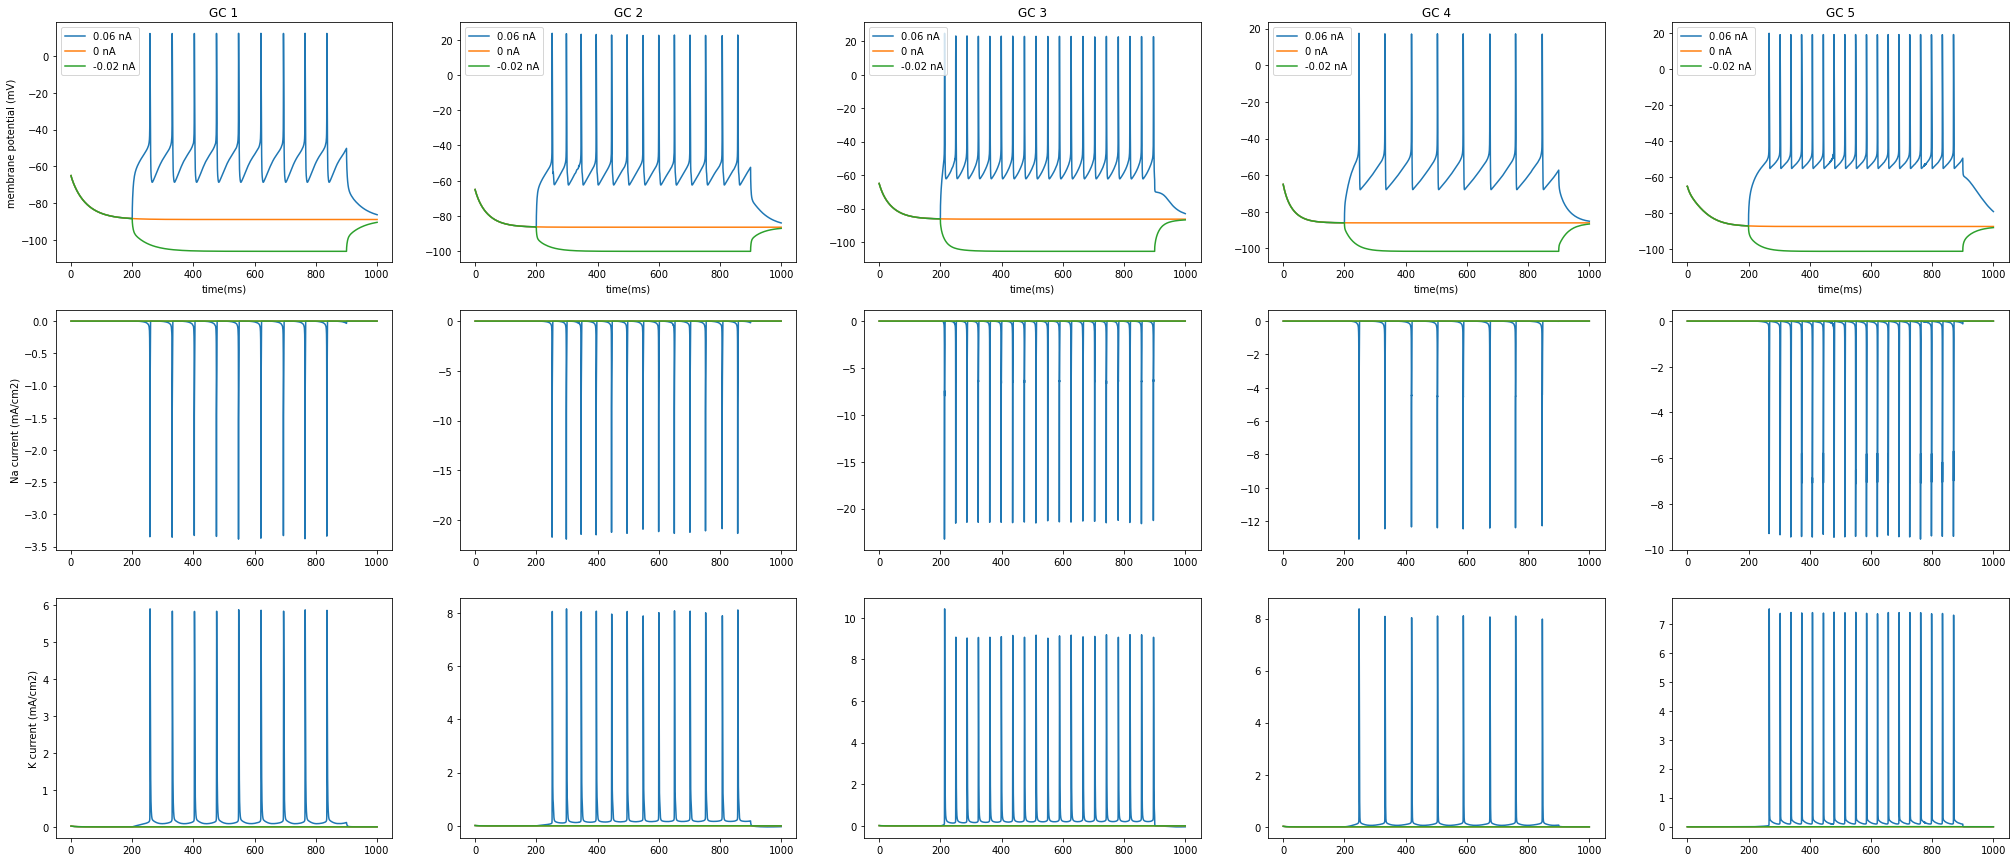

In [15]:
fig, axs = plt.subplots(3, num_gc_cells, figsize=(35,15), sharey=False)
axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)
        iNa = h.Vector().record(cell.soma(0.5)._ref_ina)
        iK = h.Vector().record(cell.soma(0.5)._ref_ik)
        #iCa = h.Vector().record(cell.soma(0.5)._ref_ica)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
        axs[idx+num_gc_cells].plot(t, iNa, label=f'{amp} nA')
        axs[idx+2*num_gc_cells].plot(t, iK, label=f'{amp} nA')

    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')
axs[5].set_ylabel('Na current (mA/cm2)')
axs[10].set_ylabel('K current (mA/cm2)')
#axs[15].set_ylabel('Ca current (mA/cm2)')

In [21]:
# Function to set up and run the stimulation
def run_stimulation(gc_cells, interval_ms=10, num_dendrites=1):
    random.seed(42)  # Setting a seed for reproducibility

    volt_soma = []
    volt_dend = []

    interval_s = interval_ms / 1000.0
    frequency_hz = 1 / interval_s

    h.cvode.active(0)  # Disable variable time-stepping globally
    fixed_dt = 0.1     # Set the fixed time step
    h.dt = fixed_dt
    h.steps_per_ms = 1 / fixed_dt  # Ensure steps_per_ms corresponds to dt

    for idx, cell in enumerate(gc_cells):
        print(f"Simulating cell {idx+1}")

        try:
            soma_sec = cell.soma
        except AttributeError:
            print(f"Error: Cell {idx+1} does not have a 'soma' attribute.")
            continue
        
        apic_secs = getattr(cell, 'apic', None)
        if apic_secs is None or not len(apic_secs):
            print(f"Error: Cell {idx+1} does not have 'apic' attribute or it is empty.")
            continue

        # Convert apic_secs to a list to sample from
        apic_secs_list = [sec for sec in apic_secs]  # Convert apic_secs to a list
        
        # Ensure the number of dendrites doesn't exceed available sections
        num_dendrites_to_stimulate = min(num_dendrites, len(apic_secs_list))
        selected_dend_secs = random.sample(apic_secs_list, num_dendrites_to_stimulate)
        
        # Generate spike times for VecStim (e.g., Poisson process or regular spikes)
        spike_times = [i * interval_ms for i in range(1000 // interval_ms)]
        vs = create_vecstim(spike_times)

        v_soma = h.Vector().record(soma_sec(0.5)._ref_v)
        v_apic = []
        for dend_sec in selected_dend_secs:
            v_dend = h.Vector().record(dend_sec(1.0)._ref_v)
            v_apic.append(v_dend)

            stim_dend = h.ExpSyn(dend_sec(1.0))
            nc_dend = h.NetCon(vs, stim_dend)
            nc_dend.threshold = -10
            nc_dend.delay = 1
            nc_dend.weight[0] = 0.04

        # Stimulation to soma
        stim_soma = h.ExpSyn(soma_sec(0.5))
        nc_soma = h.NetCon(vs, stim_soma)
        nc_soma.threshold = -10
        nc_soma.delay = 1
        nc_soma.weight[0] = 0.04

        t = h.Vector().record(h._ref_t)

        # Ensure the dt is reset for each simulation
        h.dt = fixed_dt
        h.steps_per_ms = 1 / fixed_dt

        print(f"Time step (h.dt): {h.dt}")  # Ensure that the time step is consistent
        
        h.finitialize(-65)  # Initialize to -65 mV
        h.continuerun(1000)  # Run the simulation for 1000 ms

        volt_soma.append(list(v_soma))
        volt_dend.append([list(v_dend) for v_dend in v_apic])

        # Print lengths for debugging
        print(f"Length of time vector t: {len(t)}")
        print(f"Length of soma voltage for cell {idx+1}: {len(volt_soma[-1])}")
        print(f"Length of dendrite voltage for cell {idx+1}: {len(volt_dend[-1])}")

    return frequency_hz, t, volt_soma, volt_dend

In [8]:
# Function to create and configure NetStim
def create_netstim(interval_ms=10):
    ns = h.NetStim()
    ns.interval = interval_ms  # Interval in ms
    ns.number = 1e6   # Max number of spikes
    ns.start = 0      # Start time
    ns.noise = 0.0    # No variability, deterministic
    return ns



# Function to set up and run the stimulation
def run_vecstim_stimulation(gc_cells, interval_ms=5):
    random.seed(42)  # Setting a seed for reproducibility

    volt_soma = []
    volt_dend = []

    interval_s = interval_ms / 1000.0
    frequency_hz = 1 / interval_s

    h.cvode.active(0)  # Disable variable time-stepping globally
    fixed_dt = 0.1     # Set the fixed time step
    h.dt = fixed_dt
    h.steps_per_ms = 1 / fixed_dt  # Ensure steps_per_ms corresponds to dt

    for idx, cell in enumerate(gc_cells):
        print(f"Simulating cell {idx+1}")

        try:
            soma_sec = cell.soma
        except AttributeError:
            print(f"Error: Cell {idx+1} does not have a 'soma' attribute.")
            continue
        
        apic_secs = getattr(cell, 'apic', None)
        if apic_secs is None or not apic_secs:
            print(f"Error: Cell {idx+1} does not have 'apic' attribute or it is empty.")
            continue

        selected_dend_sec = random.choice(apic_secs)
        ns = create_netstim(interval_ms)

        v_soma = h.Vector().record(soma_sec(0.5)._ref_v)
        v_apic = h.Vector().record(selected_dend_sec(1.0)._ref_v)
        stim_soma = h.ExpSyn(soma_sec(0.5))
        stim_dend = h.ExpSyn(selected_dend_sec(1.0))

        nc_soma = h.NetCon(ns, stim_soma)
        nc_soma.threshold = -10
        nc_soma.delay = 1
        nc_soma.weight[0] = 0.04

        nc_dend = h.NetCon(ns, stim_dend)
        nc_dend.threshold = -10
        nc_dend.delay = 1
        nc_dend.weight[0] = 0.04

        t = h.Vector().record(h._ref_t)

        # Ensure the dt is reset for each simulation
        h.dt = fixed_dt
        h.steps_per_ms = 1 / fixed_dt

        print(f"Time step (h.dt): {h.dt}")  # Ensure that the time step is consistent
        
        h.finitialize(-65)  # Initialize to -65 mV
        h.continuerun(1000)  # Run the simulation for 1000 ms

        volt_soma.append(list(v_soma))
        volt_dend.append(list(v_apic))

        # Print lengths for debugging
        print(f"Length of time vector t: {len(t)}")
        print(f"Length of soma voltage for cell {idx+1}: {len(volt_soma[-1])}")
        print(f"Length of dendrite voltage for cell {idx+1}: {len(volt_dend[-1])}")

    return frequency_hz, t, volt_soma, volt_dend



In [3]:
# Function to plot the results
def plot_results(frequency_hz, t, volt_soma, volt_dend):
    num_gcs = len(volt_soma)
    
    # Create a figure with subplots arranged vertically
    fig, axs = plt.subplots(num_gcs, 1, figsize=(10, 6 * num_gcs), sharex=True)
    
    # Adjust the space between subplots
    plt.subplots_adjust(hspace=0.2)
    
    for idx in range(num_gcs):
        axs[idx].plot(t, volt_soma[idx], label='Soma')
        for j, dend_volt in enumerate(volt_dend[idx]):
            axs[idx].plot(t, dend_volt, label=f'Dendrite {j+1}')
        axs[idx].set_title(f'Voltage Trace for GC {idx+1} at {frequency_hz:.1f} Hz', fontsize=14)
        axs[idx].set_xlabel('Time (ms)', fontsize=14)
        axs[idx].set_ylabel('Voltage (mV)', fontsize=14)
        axs[idx].legend(fontsize=14)
    
    plt.show()

Simulating cell 1
Time step (h.dt): 0.1
Length of time vector t: 10003
Length of soma voltage for cell 1: 10003
Length of dendrite voltage for cell 1: 10003
Simulating cell 2
Time step (h.dt): 0.1
Length of time vector t: 10003
Length of soma voltage for cell 2: 10003
Length of dendrite voltage for cell 2: 10003
Simulating cell 3
Time step (h.dt): 0.1
Length of time vector t: 10003
Length of soma voltage for cell 3: 10003
Length of dendrite voltage for cell 3: 10003
Simulating cell 4
Time step (h.dt): 0.1
Length of time vector t: 10003
Length of soma voltage for cell 4: 10003
Length of dendrite voltage for cell 4: 10003
Simulating cell 5
Time step (h.dt): 0.1
Length of time vector t: 10003
Length of soma voltage for cell 5: 10003
Length of dendrite voltage for cell 5: 10003


ValueError: x and y must have same first dimension, but have shapes (10003,) and (1,)

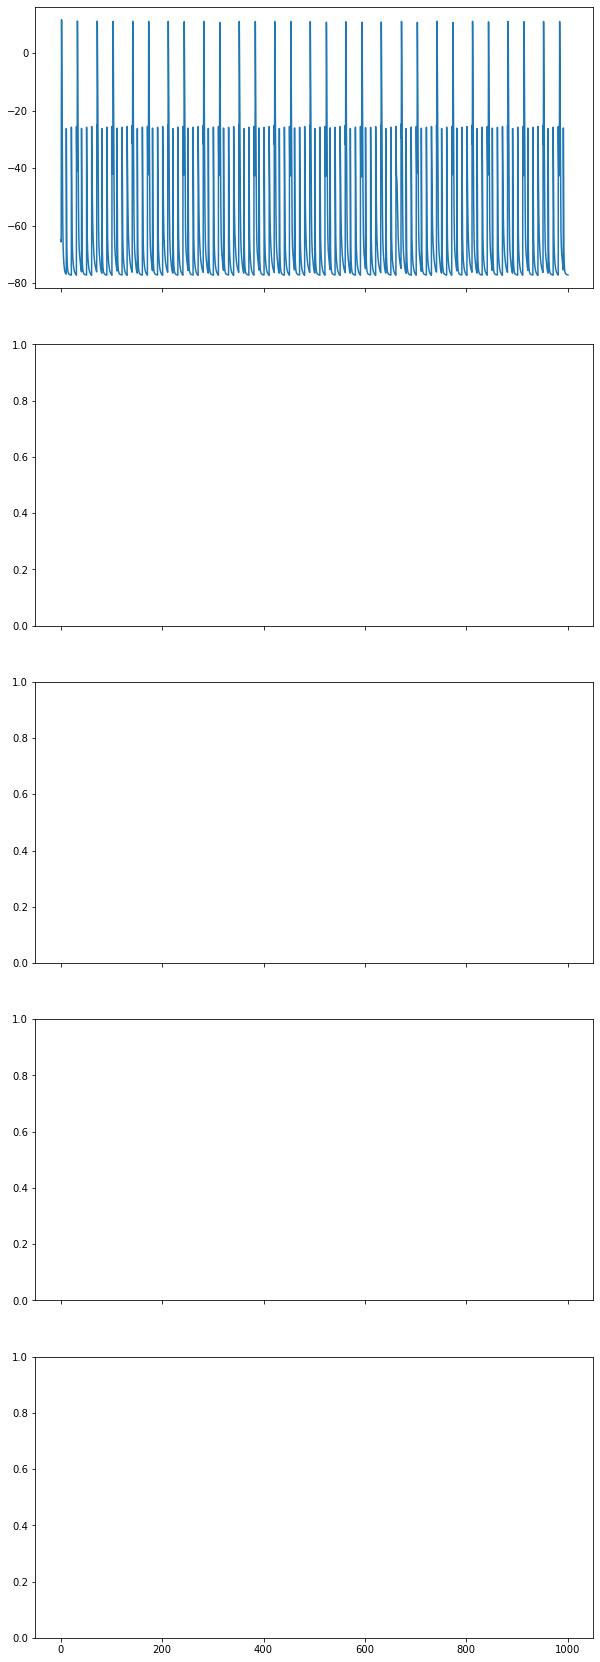

In [9]:
frequency, t, volt_soma, volt_dend = run_vecstim_stimulation(gc_cells, interval_ms=10)
plot_results(frequency, t, volt_soma, volt_dend)

In [ ]:
volt_dend

In [ ]:
gc_amps = [0.06, 0, -0.02]
gc_cells = [gc_cell]
num_gc_cells = len(gc_cells)

In [ ]:
fig, axs = plt.subplots(1, num_gc_cells, figsize=(15,5), sharey=True)
# axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs.plot(t, v, label=f'{amp} nA')
    
    axs.set_title(f'{cell.cell_type} {cell.cell_id}')

    axs.legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs.set_xlabel('time(ms)')

axs.set_ylabel('membrane potential (mV)')